# CNN Training & Reporting Notebook

Notebook này dùng để train model CNN và tạo summary/biểu đồ cho báo cáo.

# CNN Reporting Notebook

Notebook này dùng để đọc artifact từ pipeline CNN mới và tạo summary/biểu đồ cho báo cáo.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Thêm các import cần thiết
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import json
import time
from datetime import datetime

# Kiểm tra GPU
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

GPU Available: True
GPU Device: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'ai' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ai.CNN.evaluator import ModelEvaluator
from ai.CNN.feature_extraction import vector_to_mbti
from infrastructure.config_loader import load_cnn_config

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Chọn artifact cần báo cáo

In [3]:
# Cấu hình training
config = load_cnn_config(str(PROJECT_ROOT / 'config' / 'cnn_config.yaml'))

# Thay đổi các hyperparameters nếu cần (optional)
# config['training']['learning_rate'] = 0.0005  # Giảm learning rate nếu cần
# config['training']['epochs'] = 30  # Tăng số epochs
# config['training']['batch_size'] = 32  # Tăng batch size

training_cfg = config.get('training', {})
print("⚙️ Training Config:")
print(f"  • Learning Rate: {training_cfg.get('learning_rate')}")
print(f"  • Epochs: {training_cfg.get('epochs')}")
print(f"  • Batch Size: {training_cfg.get('batch_size')}")
print(f"  • Early Stopping Patience: {training_cfg.get('early_stopping_patience')}")
print(f"  • Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")


⚙️ Training Config:
  • Learning Rate: 0.0005
  • Epochs: 50
  • Batch Size: 32
  • Early Stopping Patience: 10
  • Device: GPU


## 3. Load & Prepare Training Data

In [4]:
RUN_NAME = 'cnn_real'

model_dir = PROJECT_ROOT / 'models' / RUN_NAME
history_path = model_dir / 'training_history.json'
metrics_path = PROJECT_ROOT / 'outputs' / 'cnn_real_metrics.json'
X_test_path = model_dir / 'X_test.npy'
y_test_path = model_dir / 'y_test.npy'
model_path = model_dir / 'audio_cnn.pt'

for path in [history_path, metrics_path, X_test_path, y_test_path, model_path]:
    print(path, 'OK' if path.exists() else 'MISSING')


D:\project\models\cnn_real\training_history.json OK
D:\project\outputs\cnn_real_metrics.json OK
D:\project\models\cnn_real\X_test.npy OK
D:\project\models\cnn_real\y_test.npy OK
D:\project\models\cnn_real\audio_cnn.pt OK


## 3. Load dữ liệu báo cáo

In [5]:
with open(history_path, 'r', encoding='utf-8') as f:
    history = json.load(f)

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics = json.load(f)

X_test = np.load(X_test_path)
y_test = np.load(y_test_path)

history_df = pd.DataFrame(history)
metrics_df = pd.DataFrame(metrics['dimensions']).T.reset_index().rename(columns={'index': 'dimension'})
summary_df = pd.DataFrame([
    {
        'overall_dimension_accuracy': metrics['overall_dimension_accuracy'],
        'overall_dimension_f1': metrics['overall_dimension_f1'],
        'full_type_accuracy': metrics['full_type_accuracy'],
        'sample_count': metrics['sample_count'],
    }
])

display(summary_df)
display(metrics_df)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)


,overall_dimension_accuracy,overall_dimension_f1,full_type_accuracy,sample_count
0,0.53125,0.447619,0.125,8


,dimension,accuracy,f1,roc_auc
0,E/I,0.375,0.000000,0.600000
1,S/N,0.750,0.857143,0.500000
2,T/F,0.500,0.333333,0.533333
3,J/P,0.500,0.600000,0.533333


X_test shape: (8, 128, 1290, 1)
y_test shape: (8, 4)


In [6]:
# Import training modules
from ai.CNN.trainer import ModelTrainer
from ai.CNN.model import AudioCNN

# Chuẩn bị thư mục output
RUN_NAME = 'cnn_real'
output_dir = PROJECT_ROOT / 'models' / RUN_NAME
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir}")

# Đường dẫn tới dữ liệu
X_path = PROJECT_ROOT / 'data' / 'X_train.npy'
y_path = PROJECT_ROOT / 'data' / 'y_train.npy'

if not X_path.exists() or not y_path.exists():
    print("Chưa có dữ liệu training (X_train.npy, y_train.npy)")
    print(f"   Cần extract features trước bằng feature_extraction.py")
else:
    print(f"Dữ liệu training tìm thấy")
    X = np.load(X_path)
    y = np.load(y_path)
    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")

Output directory: D:\project\models\cnn_real
Dữ liệu training tìm thấy
   X shape: (1595, 128, 1290, 1)
   y shape: (1595, 4)


In [7]:
if X_path.exists() and y_path.exists():
    print("Bắt đầu training...\n")
    
    trainer = ModelTrainer(config)
    start_time = time.time()
    
    # Run training
    results = trainer.train(str(X_path), str(y_path), str(output_dir))
    
    training_time = time.time() - start_time
    
    # Load training history
    history_file = Path(results['history_path'])
    with open(history_file, 'r') as f:
        history = json.load(f)
    
    print(f"\nTraining hoàn tất!")
    print(f"Thời gian training: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
    print(f"Test Loss: {results['test_loss']}")
    print(f"Model saved: {results['model_path']}")
    print(f"History saved: {results['history_path']}")
    
    # Hiển thị training statistics
    epochs_trained = len(history['train_loss'])
    train_loss_final = history['train_loss'][-1]
    val_loss_final = history['val_loss'][-1]
    best_val_loss = min(history['val_loss'])
    best_epoch = history['val_loss'].index(best_val_loss) + 1
    
    print(f"\n Training Statistics:")
    print(f"  • Epochs trained: {epochs_trained}")
    print(f"  • Final train loss: {train_loss_final:.6f}")
    print(f"  • Final val loss: {val_loss_final:.6f}")
    print(f"  • Best val loss: {best_val_loss:.6f} (at epoch {best_epoch})")
    print(f"  • Improvement: {((val_loss_final - best_val_loss) / best_val_loss * 100):.2f}% worse than best")

Bắt đầu training...


Training hoàn tất!
Thời gian training: 9036.46 seconds (150.61 minutes)
Test Loss: 0.751509
Model saved: D:\project\models\cnn_real\audio_cnn.pt
History saved: D:\project\models\cnn_real\training_history.json

📈 Training Statistics:
  • Epochs trained: 17
  • Final train loss: 0.663559
  • Final val loss: 0.808049
  • Best val loss: 0.686720 (at epoch 7)
  • Improvement: 17.67% worse than best


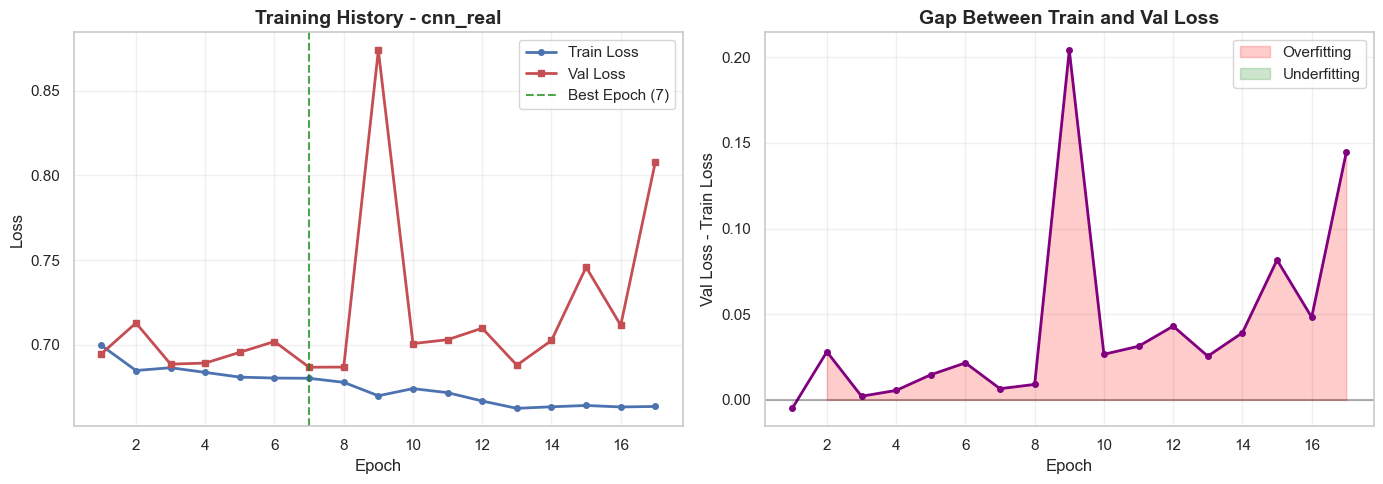

💡 Giải thích:
  • Purple curve dương = Overfitting (model học quá fit training data)
  • Purple curve âm = Underfitting (model chưa đủ tốt)
  • Green line = Best epoch (giữ best model)


In [8]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title(f'Training History - {RUN_NAME}', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Loss difference (overfitting indicator)
loss_diff = np.array(history['val_loss']) - np.array(history['train_loss'])
ax2.plot(epochs_range, loss_diff, 'purple', marker='o', linewidth=2, markersize=4)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.fill_between(epochs_range, 0, loss_diff, where=(loss_diff > 0), alpha=0.2, color='red', label='Overfitting')
ax2.fill_between(epochs_range, 0, loss_diff, where=(loss_diff <= 0), alpha=0.2, color='green', label='Underfitting')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Val Loss - Train Loss', fontsize=12)
ax2.set_title('Gap Between Train and Val Loss', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Giải thích:")
print("  • Purple curve dương = Overfitting (model học quá fit training data)")
print("  • Purple curve âm = Underfitting (model chưa đủ tốt)")
print("  • Green line = Best epoch (giữ best model)")

## 6. Evaluate Model on Test Set

In [14]:
# Load test data và model để evaluate
test_split = np.load(str(output_dir / 'test_split.npz'))
X_test = test_split['X_test']
y_test = test_split['y_test']

config = load_cnn_config(str(PROJECT_ROOT / 'config' / 'cnn_config.yaml'))
evaluator = ModelEvaluator(config)
model = evaluator.load_model(str(output_dir / 'audio_cnn.pt'))

# Tính metrics
metrics = evaluator.evaluate(model, X_test, y_test)

# Save metrics
metrics_path = PROJECT_ROOT / 'outputs' / f'{RUN_NAME}_metrics.json'
metrics_path.parent.mkdir(parents=True, exist_ok=True)
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print("📊 Test Set Evaluation:")
print(f"  • Samples: {len(X_test)}")
print(f"  • Overall Dimension Accuracy: {metrics['overall_dimension_accuracy']:.4f}")
print(f"  • Overall Dimension F1: {metrics['overall_dimension_f1']:.4f}")
print(f"  • Full Type Accuracy: {metrics['full_type_accuracy']:.4f}")

AttributeError: 'AudioCNN' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

## 7. Per-Dimension Metrics (Chi tiết từng chiều MBTI)


📈 Metrics per dimension:
dimension  accuracy       f1  roc_auc
      E/I     0.375 0.000000 0.600000
      S/N     0.750 0.857143 0.500000
      T/F     0.500 0.333333 0.533333
      J/P     0.500 0.600000 0.533333



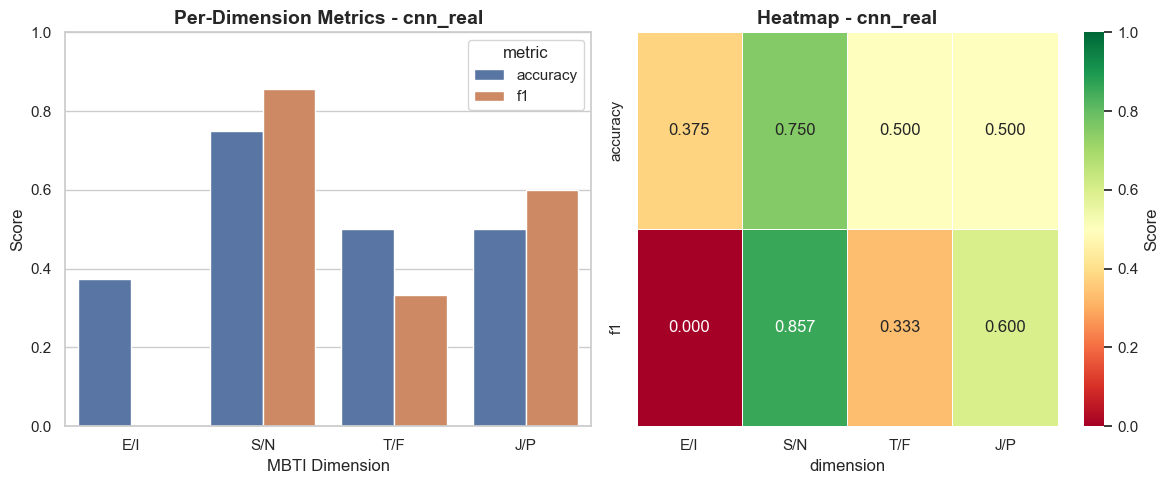

In [10]:
metrics_df = pd.DataFrame(metrics['dimensions']).T.reset_index().rename(columns={'index': 'dimension'})
print("\n📈 Metrics per dimension:")
print(metrics_df.to_string(index=False))
print()

# Visualize
plot_df = metrics_df.melt(id_vars='dimension', value_vars=['accuracy', 'f1'], var_name='metric', value_name='value')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.barplot(data=plot_df, x='dimension', y='value', hue='metric', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title(f'Per-Dimension Metrics - {RUN_NAME}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('MBTI Dimension', fontsize=12)

# Heatmap
pivot_df = metrics_df.set_index('dimension')[['accuracy', 'f1']]
sns.heatmap(pivot_df.T, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, 
            cbar_kws={'label': 'Score'}, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'Heatmap - {RUN_NAME}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Confusion Matrix for Each Dimension

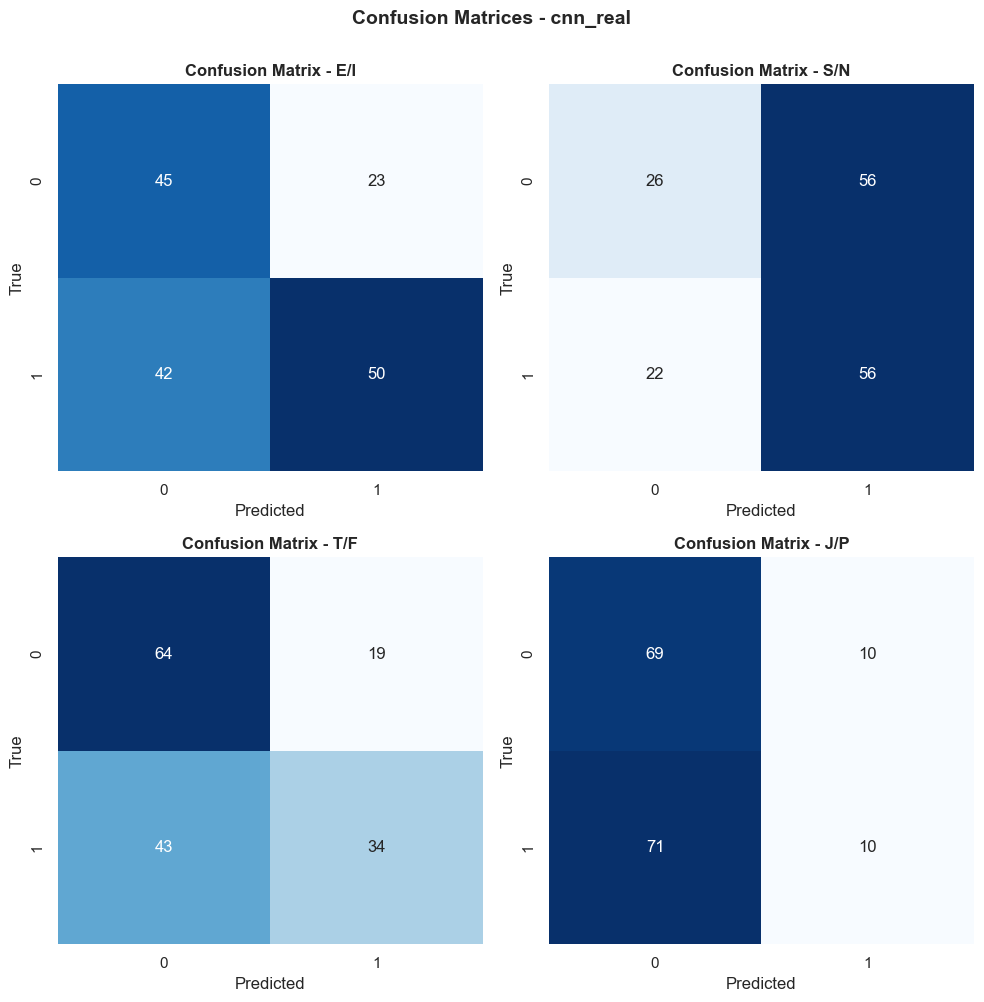

✅ Chi tiết confusion matrix cho mỗi chiều MBTI


In [11]:
# Load predictions
probs = evaluator.predict_logits(model, X_test)
preds = (probs >= 0.5).astype(int)

dimension_names = ['E/I', 'S/N', 'T/F', 'J/P']
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for idx, name in enumerate(dimension_names):
    cm = confusion_matrix(y_test[:, idx].astype(int), preds[:, idx].astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.suptitle(f'Confusion Matrices - {RUN_NAME}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Chi tiết confusion matrix cho mỗi chiều MBTI")

## 9. Compare True vs Predicted MBTI Types

In [12]:
from ai.CNN.feature_extraction import vector_to_mbti

report_df = pd.DataFrame({
    'true_mbti': [vector_to_mbti(row) for row in y_test],
    'pred_mbti': [vector_to_mbti(row) for row in preds],
})
report_df['match'] = report_df['true_mbti'] == report_df['pred_mbti']

print(f"\nSample Predictions (50 mẫu đầu tiên):")
print(report_df.head(50).to_string(index=False))
print(f"\n... (Total {len(report_df)} samples)")
print(f"\nChính xác: {report_df['match'].sum()} / {len(report_df)} ({report_df['match'].mean()*100:.2f}%)")

# Breakdown by MBTI type
type_accuracy = report_df.groupby('true_mbti')['match'].agg(['sum', 'count'])
type_accuracy['accuracy'] = type_accuracy['sum'] / type_accuracy['count']
type_accuracy = type_accuracy.rename(columns={'sum': 'correct', 'count': 'total'})
type_accuracy = type_accuracy.sort_values('accuracy', ascending=False)

print(f"\n Accuracy per MBTI Type:")
print(type_accuracy.to_string())


Sample Predictions (50 mẫu đầu tiên):
true_mbti pred_mbti  match
     INFP      INFP   True
     INTP      ESFP  False
     ISFJ      ISFP  False
     ENTP      ISFP  False
     ISTJ      ISFP  False
     ENFP      ISFJ  False
     ISFJ      ISFJ   True
     ESFP      ISFJ  False
     INTJ      INTP  False
     ESTJ      ISFP  False
     ESTJ      INTP  False
     ENTP      ESFP  False
     ESFP      INFP  False
     ISTP      ISFP  False
     ISFJ      INFP  False
     ESTJ      INTP  False
     ENFJ      ESTP  False
     ENTJ      ESTP  False
     INFJ      ISFP  False
     ISFP      INFP  False
     ISTP      INFJ  False
     ESFP      ESFP   True
     ISTP      ESTP  False
     ENFP      ISFJ  False
     ENFJ      ISFP  False
     ESTJ      ESFP  False
     ISFJ      ISFP  False
     ISTJ      INFP  False
     ENTJ      ESFP  False
     INFP      ESFP  False
     ENTP      ESFP  False
     ENFJ      ISFP  False
     INTJ      ISFP  False
     INFP      ESFP  False
     ENTJ      I